# Размита логика: Препоръка за скорост при шофиране

Този notebook демонстрира създаването на система с размита логика (Fuzzy Logic) за определяне на препоръчителна скорост въз основа на три фактора: **трафик**, **време** и **видимост**.

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Дефиниране на входове (Antecedents) и изход (Consequent)
traffic = ctrl.Antecedent(np.arange(0, 11, 1), 'traffic')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
visibility = ctrl.Antecedent(np.arange(0, 11, 1), 'visibility')

speed = ctrl.Consequent(np.arange(0, 131, 1), 'speed')

## 2. Функции за принадлежност (Membership Functions)

Генерираме категориите автоматично или ги дефинираме ръчно. За "Време" и "Видимост" използваме автоматични `poor`, `average` и `good`.

In [3]:
# Автоматично създаваме 'poor', 'average', 'good'
weather.automf(3)
visibility.automf(3)

# Ръчно дефинираме трафика за повече прецизност
traffic['light'] = fuzz.trimf(traffic.universe, [0, 0, 5])
traffic['moderate'] = fuzz.trimf(traffic.universe, [0, 5, 10])
traffic['heavy'] = fuzz.trimf(traffic.universe, [5, 10, 10])

# Ръчно дефинираме и изхода (скорост в км/ч)
speed['slow'] = fuzz.trimf(speed.universe, [0, 0, 65])
speed['medium'] = fuzz.trimf(speed.universe, [0, 65, 130])
speed['fast'] = fuzz.trimf(speed.universe, [65, 130, 130])

Можем да визуализираме как изглеждат нашите функции за принадлежност:

/Users/alex.kadiyski/Developer/Fuzzy/.env/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


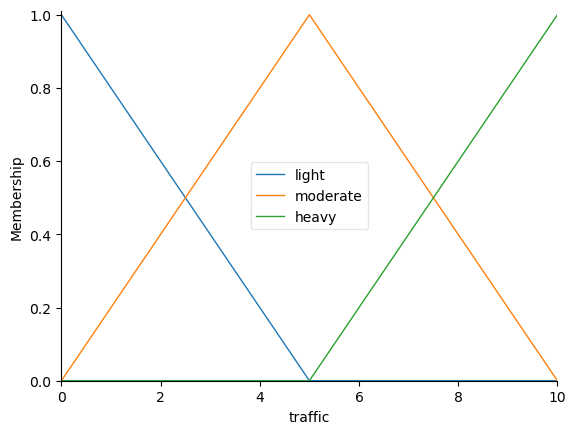

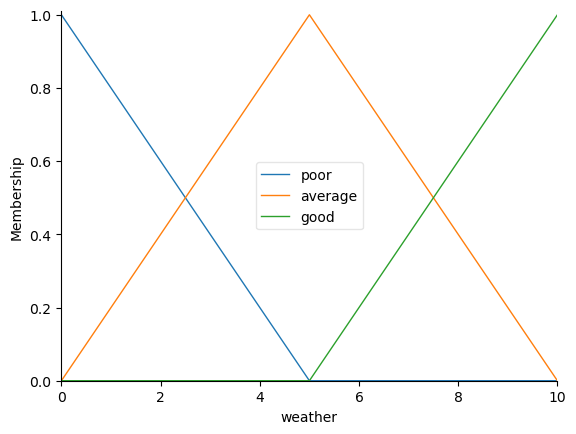

In [4]:
traffic.view()
weather.view()

## 3. Правила на системата (Fuzzy Rules)
Определяме как системата да реагира при различни условия спрямо заложените Membership функции.

In [5]:
rule1 = ctrl.Rule(weather['poor'] | visibility['poor'] | traffic['heavy'], speed['slow'])
rule2 = ctrl.Rule(traffic['moderate'] | (weather['average'] & visibility['average']), speed['medium'])
rule3 = ctrl.Rule(weather['good'] & visibility['good'] & traffic['light'], speed['fast'])

## 4. Инициализация на системата и Симулация
Създаваме контролера и подаваме примерни стойности.

In [6]:
speed_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
driving_sim = ctrl.ControlSystemSimulation(speed_ctrl)

# Подаваме примерни входни параметри (например перфектни условия и умерен трафик)
driving_sim.input['traffic'] = 10.0
driving_sim.input['weather'] = 10.0
driving_sim.input['visibility'] = 3.0

driving_sim.compute()

print(f"Препоръчителната скорост е: {driving_sim.output['speed']:.2f} км/ч")

Препоръчителната скорост е: 21.67 км/ч


## 5. Графична визуализация на крайния резултат

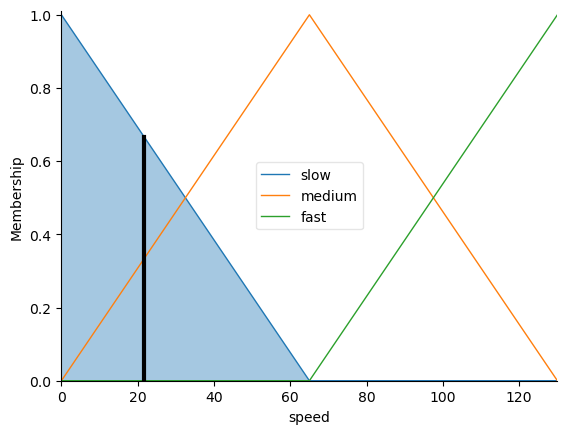

In [7]:
speed.view(sim=driving_sim)
plt.show()